# Annualization and seasonalization

`.x.annualize()` collapses a monthly series into annual or seasonal means, with
optional day-length weighting.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)
da = ds.x.da
print(da.sizes)

Frozen({'time': 60, 'ncol': 13826})


## Calendar-year means

With no arguments, `annualize` averages each calendar year.

In [3]:
ann = da.x.annualize()
print('months in ->', da.sizes['time'])
print('years out ->', ann.sizes['time'])
print(np.round(ann.x.gm.values, 3))

months in -> 60
years out -> 5
[296.395 296.354 296.508 296.504 296.215]


## Day-length weighting

Months are not the same length, so a plain mean over-weights February. Pass
`days_weighted=True` to weight each month by its number of days.

The weights are normalized over **each output bin**, not over the calendar year.
That distinction matters for wraparound seasons and for incomplete bins at the ends
of a record — see the DJF example below.

In [4]:
ann_w = da.x.annualize(days_weighted=True)

print('unweighted :', np.round(ann.x.gm.values, 4))
print('weighted   :', np.round(ann_w.x.gm.values, 4))
print('difference :', np.round((ann_w.x.gm - ann.x.gm).values, 4))

unweighted : [296.3948 296.3538 296.5076 296.5039 296.2154]
weighted   : [296.3999 296.3595 296.5133 296.5086 296.221 ]
difference : [0.0051 0.0057 0.0057 0.0047 0.0057]


## Seasons

`months` takes a list of month numbers. A **negative** month means "take it from the
previous year", which is how you express a season that straddles the year boundary.

In [5]:
jja = da.x.annualize(months=[6, 7, 8])
son = da.x.annualize(months=[9, 10, 11])

# DJF: December belongs to the *previous* calendar year
djf = da.x.annualize(months=[-12, 1, 2])

for name, x in [('JJA', jja), ('SON', son), ('DJF', djf)]:
    print(f'{name}: {x.sizes["time"]} bins, global means {np.round(x.x.gm.values, 2)}')

JJA: 5 bins, global means [297.81 297.77 297.96 297.9  297.66]
SON: 5 bins, global means [296.11 296.26 296.47 296.28 296.05]
DJF: 6 bins, global means [295.16 295.08 295.09 295.42 294.97 294.68]


DJF returns one more bin than JJA over the same record: the first bin has only
January and February (no preceding December) and the last has only December. Those
partial bins are averaged over what is actually present rather than being scaled as
if the whole season were there.

In [6]:
djf_w = da.x.annualize(months=[-12, 1, 2], days_weighted=True)
print('DJF time stamps :', [str(t)[:10] for t in djf.time.values])
print('DJF unweighted  :', np.round(djf.x.gm.values, 3))
print('DJF day-weighted:', np.round(djf_w.x.gm.values, 3))

DJF time stamps : ['0001-02-28', '0002-02-28', '0003-02-28', '0004-02-28', '0005-02-28', '0006-02-28']
DJF unweighted  : [295.156 295.079 295.09  295.424 294.965 294.676]
DJF day-weighted: [295.14  295.069 295.078 295.415 294.956 294.676]


## Climatology and anomalies

`.x.climo` is the monthly climatology (12 bins); `.x.anom` removes it, month by
month.

In [7]:
climo = da.x.climo
anom = da.x.anom

print('climo :', dict(climo.sizes), '| period', climo.attrs['climo_period'])
print('anom  :', dict(anom.sizes))

climo : {'time': 12, 'ncol': 13826} | period (np.int64(1), np.int64(5))
anom  : {'time': 60, 'ncol': 13826}


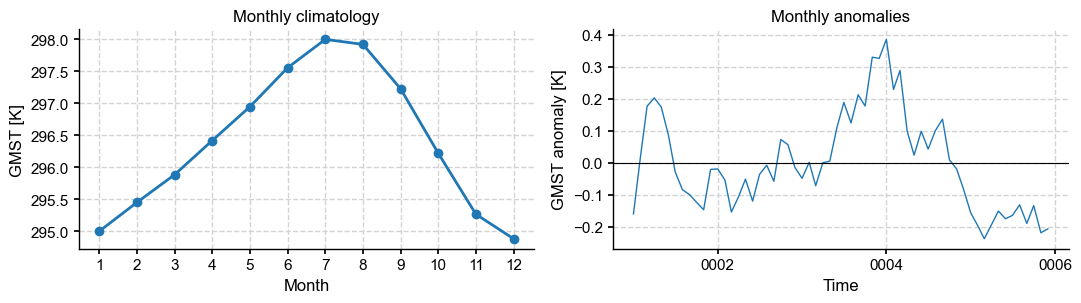

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(climo.time, climo.x.gm, marker='o')
axes[0].set(xlabel='Month', ylabel='GMST [K]', title='Monthly climatology',
            xticks=range(1, 13))
axes[1].plot(anom.time, anom.x.gm, lw=1)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set(xlabel='Time', ylabel='GMST anomaly [K]', title='Monthly anomalies')
fig.tight_layout()
x4c.showfig(fig)